In [3]:
import json
import pandas as pd
import os
from benchmarks import load_reframe_report, get_performance_tables, post_process_cbenchio_table
from matplotlib import pyplot as plt
import seaborn as sns
import re
import numpy as np
sns.set_style("whitegrid")

In [4]:
def get_file_system(path: str) -> str:
    """Get the file system type for a given path.
    Args:
        path (str): The file path to check.

    Returns:
        str: The file system type ("VAST" or "LUSTRE").
    """
    
    if "vast" in path.split(os.sep):
        return "vast"
    else:
        return "lustre"

def load_cbenchio_reports(filenames):
    experiments=[]
    for filename in filenames:
        data= load_reframe_report(filename)
        tables=get_performance_tables(data)
        for test_case, table in tables.items():
            data = post_process_cbenchio_table(table)

            # Set defaults parameters 
            if "stripes" not in data.columns:
                data["stripes"] = "1"
            if "field_size_per_process_per_dimension" not in data.columns:
                data["field_size_per_process_per_dimension"] = "1048576"

            # Convert to MiB
            data["field_size_per_process_per_dimension"]=(data["field_size_per_process_per_dimension"].astype(int)/2**20 ).astype(int)

            # Replace the number of stripes with the number of nodes when the number of stripes is set to "num_nodes"

       
            
            selection = data["stripes"] == "num_nodes"
            data.loc[selection, "stripes"] = data.loc[selection, "nodes"]


            data["nodes"] = data["nodes"].astype(int)
            data["tasks_per_node"] = data["tasks_per_node"].astype(int)
                
            data["stripes"] = data["stripes"].astype(int)
            data["filesystem"] = [get_file_system(base_path) for base_path in data["base_path"]]


            experiments.append(data)
    
    data=pd.concat(experiments).reset_index(drop=True).dropna()
    return data

def get_report_filenames(base_path, pattern="*.json", exclude_pattern=None):
    """Get a list of report filenames in the specified base path that match the given pattern and do not match the exclude pattern.
    Args:
        base_path (str): The base path to search for report files.
        pattern (str): The pattern to match report files (default: "*.json").
        exclude_pattern (str): The pattern to exclude report files (default: None).      
    Returns:
        list: A list of report filenames that match the given pattern and do not match the exclude pattern.         
    """
    report_filenames = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            for pat in [pattern] if isinstance(pattern, str) else pattern:
                if re.match(pat, file) and (exclude_pattern is None or not re.match(exclude_pattern, file)):
                    report_filenames.append(os.path.join(root, file))
    return report_filenames


In [5]:
base_path="/work/z19/z19/lparisi/nfs-testing/run-reframe/"
filenames= ["mpi1DLustreN1-16T1-288Snum_nodesF4-32M.json","mpi1DVastN1-16T1-288Snum_nodesF4-32M.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))

In [87]:
## Single node performance , MPIIO 1D writes

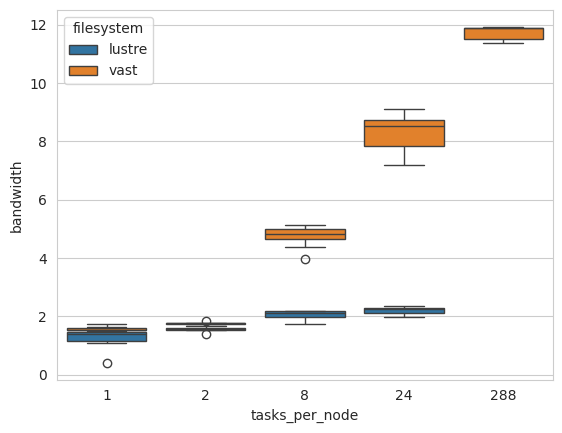

In [6]:
plot_data = data.query("nodes==1 & field_size_per_process_per_dimension==32 & stripes == 1 & name=='cbenchio_mpi_1D_write'")
sns.boxplot(data=plot_data, x="tasks_per_node", y="bandwidth", hue="filesystem",dodge=False)
plt.savefig("single_node_performance_mpi_1D.png", dpi=300, bbox_inches="tight")


In [26]:
## Sequential POSIX

In [28]:
base_path="/work/z19/z19/lparisi/nfs-testing/run-reframe/"
filenames= ["posixVASTN1T1-288C4K-32MF0.5G.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["chunk_size"]= data["chunk_size"].astype(int)/2**10
data

,name,nodes,tasks_per_node,base_path,api,chunk_size,field_size_per_process_per_dimension,bandwidth,stripes,filesystem
0,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,4.0,512,1.851014,1,vast
1,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,1024.0,512,4.956691,1,vast
2,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,4096.0,512,3.532827,1,vast
3,cbenchio_posix_sequential_write,1,1,/vast/lparisi/data,posix,32768.0,512,5.305430,1,vast
4,cbenchio_posix_sequential_write,1,2,/vast/lparisi/data,posix,4.0,512,2.327558,1,vast
...,...,...,...,...,...,...,...,...,...,...
507,cbenchio_posix_sequential_read,1,96,/vast/lparisi/data,posix,32768.0,512,23.068088,1,vast
508,cbenchio_posix_sequential_read,1,288,/vast/lparisi/data,posix,4.0,512,23.226819,1,vast
509,cbenchio_posix_sequential_read,1,288,/vast/lparisi/data,posix,1024.0,512,22.933679,1,vast
510,cbenchio_posix_sequential_read,1,288,/vast/lparisi/data,posix,4096.0,512,23.897023,1,vast


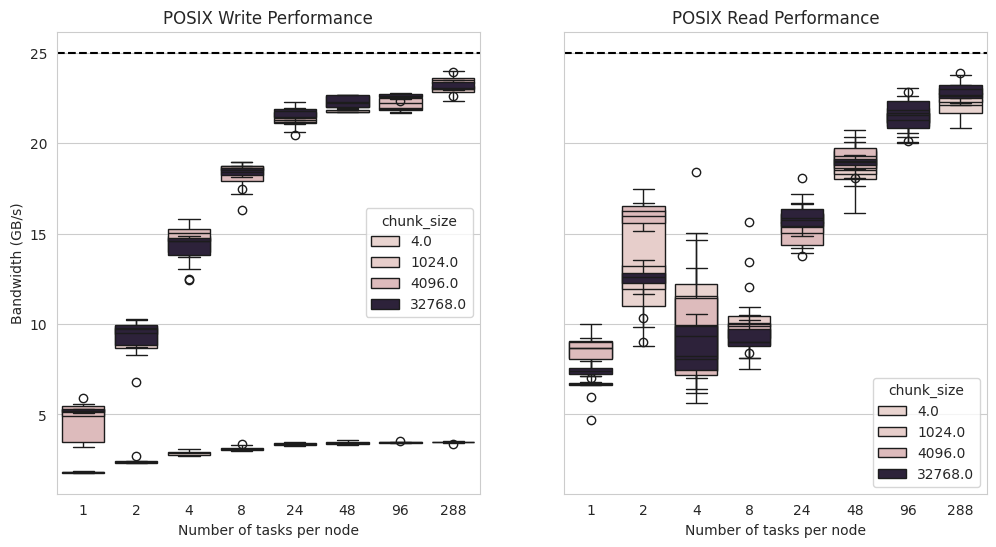

In [29]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i,operation in enumerate(["write","read"]):
    plot_data=data.query(f"name=='cbenchio_posix_sequential_{operation}'")
    #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
    sns.boxplot(ax=axes[i], data=plot_data, x="tasks_per_node", y="bandwidth", hue="chunk_size",dodge=False)
    axes[i].set_ylabel("Bandwidth (GB/s)")
    axes[i].set_xlabel("Number of tasks per node")
    axes[i].set_title(f"POSIX {operation.capitalize()} Performance")

    # Horizontal line at 25GB/s
    axes[i].axhline(y=25, color='black', linestyle='--')

plt.savefig("single_node_performance_VAST_posix.png", dpi=300, bbox_inches="tight")


In [ ]:
## Random POSIX

In [ ]:
base_path="/work/z19/z19/lparisi/nfs-testing/run-reframe/"
filenames= ["posixVASTN1RandomF0.5G.json","posixVASTN1-16T1-288C4K-32MRandom.json"]

data=load_cbenchio_reports(get_report_filenames(base_path, filenames))
data["chunk_size"]= data["chunk_size"].astype(str)
set(data["nodes"])

{1}

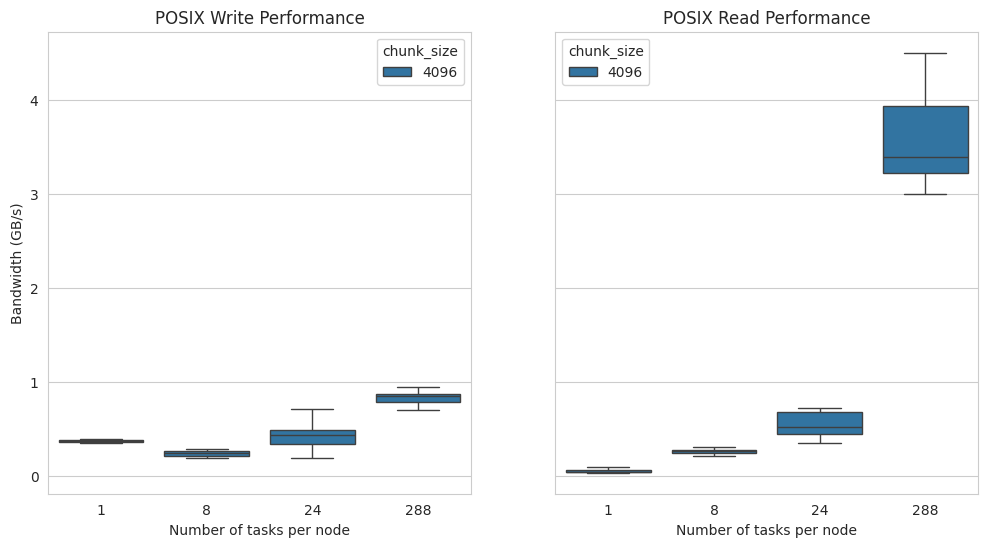

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i,operation in enumerate(["write","read"]):
    plot_data=data.query(f"name=='cbenchio_posix_random_{operation}' & chunk_size=='4096'")
    #plot_data["chunk_size"]=(np.array(plot_data["chunk_size"]).astype(float).astype(int)).astype(str) + " KiB"
    sns.boxplot(ax=axes[i], data=plot_data, x="tasks_per_node", y="bandwidth", hue="chunk_size",dodge=False)
    axes[i].set_ylabel("Bandwidth (GB/s)")
    axes[i].set_xlabel("Number of tasks per node")
    axes[i].set_title(f"POSIX {operation.capitalize()} Performance")

plt.savefig("single_node_performance_VAST_posix.png", dpi=300, bbox_inches="tight")
